# Graphing the Data
## Imports

In [1]:
import pandas as pd
import numpy as np
from currency_converter import CurrencyConverter, ECB_URL

# Needed for Plotly
import plotly.express as px
import plotly.tools as tools
import plotly.graph_objects as go

# Needed for Seaborn
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib.ticker as ticker

## Run helpers and read in data

In [2]:
%run helpers.ipynb

In [3]:
oscar_with_imdb, imdb_non_oscar = read_data('oscar_with_imdb.csv', 'imdb_non_oscar.csv')

To plot all films at once regardless of nomination status, we use the columns as series to concatenate them into a data frame. This allows the budget and box office variables to be used as combined axes for Plotly Express.

In [4]:
oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row == True else 'Nominated')
imdb_non_oscar['Status'] = 'No nomination'

budget_nom = oscar_with_imdb['budget']
gross_nom = oscar_with_imdb['gross_worldwide']

budget_imdb = imdb_non_oscar['budget']
gross_imdb = imdb_non_oscar['gross_worldwide']

oscar_noms = pd.concat([budget_nom, gross_nom, oscar_with_imdb['Status']], axis=1)
non_noms = pd.concat([budget_imdb, gross_imdb, imdb_non_oscar['Status']], axis=1)

combined_films = pd.concat([oscar_noms, non_noms], axis=0)
combined_films.dropna(how='any', inplace=True)

In [5]:
combined_films.shape

(14072, 3)

In [6]:
temp = oscar_with_imdb[oscar_with_imdb['Status'] == 'Nominated']

In [7]:
temp

,Unnamed: 0,Unnamed: 0_x,Ceremony,Year,Class,CanonicalCategory,Category,Film,FilmId,Name,...,opening_weekend_gross,gross_worldwide,gross_us_canada,release_date,countries_origin,production_companies,genres,languages,_merge,Status
0,0,0,1,1928,Acting,ACTOR IN A LEADING ROLE,ACTOR,The Noose,tt0019217,Richard Barthelmess,...,NaN,NaN,NaN,1928-01-29,['United States'],['First National Pictures'],['Drama'],"['None', 'English']",both,Nominated
1,1,1,1,1928,Acting,ACTOR IN A LEADING ROLE,ACTOR,The Patent Leather Kid,tt0018253,Richard Barthelmess,...,NaN,NaN,NaN,1927-09-01,['United States'],['First National Pictures'],"['Boxing', 'Drama', 'Romance', 'Sport', 'War']","['None', 'English']",both,Nominated
4,4,4,1,1928,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,A Ship Comes In,tt0018389,Louise Dresser,...,NaN,NaN,NaN,1928-06-04,['United States'],['DeMille Pictures Corporation'],['Drama'],['None'],both,Nominated
8,8,8,1,1928,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,Sadie Thompson,tt0019344,Gloria Swanson,...,NaN,NaN,NaN,1928-01-07,['United States'],['Gloria Swanson Pictures'],['Drama'],['English'],both,Nominated
9,9,9,1,1928,Production,ART DIRECTION,ART DIRECTION,Sunrise,tt0018455,Rochus Gliese,...,NaN,"$121,848",NaN,1927-11-04,['United States'],['Fox Film Corporation'],"['Dark Romance', 'Psychological Drama', 'Drama...","['None', 'English']",both,Nominated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9067,9067,11990,97,2024,Writing,WRITING (Adapted Screenplay),WRITING (Adapted Screenplay),Sing Sing,tt28479262,"Screenplay by Clint Bentley, Greg Kwedar; Stor...",...,"$137,119","$5,281,415","$3,110,476",2024-08-02,['United States'],"['Black Bear', 'Edith Productions', 'Marfa Pea...",['Drama'],['English'],both,Nominated
9069,9069,11992,97,2024,Writing,WRITING (Original Screenplay),WRITING (Original Screenplay),The Brutalist,tt8999762,"Written by Brady Corbet, Mona Fastvold",...,"$266,791","$48,520,129","$16,279,129",2025-01-24,"['United States', 'United Kingdom', 'Canada']","['Brookstreet Pictures', 'Kaplan Morrison', 'I...","['Epic', 'Drama']","['English', 'Hungarian', 'Italian', 'Hebrew', ...",both,Nominated
9070,9070,11993,97,2024,Writing,WRITING (Original Screenplay),WRITING (Original Screenplay),A Real Pain,tt21823606,Written by Jesse Eisenberg,...,"$228,856","$24,500,173","$8,344,978",2024-11-01,"['United States', 'Poland']","['Topic Studios', 'Extreme Emotions', 'Fruit T...","['Buddy Comedy', 'Comedy', 'Drama']","['English', 'Polish']",both,Nominated
9071,9071,11994,97,2024,Writing,WRITING (Original Screenplay),WRITING (Original Screenplay),September 5,tt28082769,"Written by Moritz Binder, Tim Fehlbaum; Co-Wri...",...,"$80,802","$8,041,940","$2,508,723",2025-01-17,"['Germany', 'United States']","['BerghausWöbke Filmproduktion', 'Projected Pi...","['Docudrama', 'Period Drama', 'Tragedy', 'Dram...","['English', 'German', 'Hebrew']",both,Nominated


## Setting up data for scatter plot (Budget vs Box Office)

We want to categorize films by their academy award status or if they were not nominated. We begin by adding False entries to the `Winner` field in the joined data frame for Academy Award films, and then dropping any NA values in both joined data frames.

### Create `Status` field

In [8]:
temp_oscar_with_imdb = oscar_with_imdb.dropna(subset=['budget', 'gross_worldwide'])
temp_imdb_non_oscar = imdb_non_oscar.dropna(subset=['budget', 'gross_worldwide'])

# Nominess are marked as NaN so we replace with False
temp_oscar_with_imdb['Winner'] = oscar_with_imdb['Winner'].fillna(False)

In [9]:
temp_oscar_with_imdb['Status'] = temp_oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row else 'Nominated')

winners = temp_oscar_with_imdb[temp_oscar_with_imdb['Status'] == 'Winner']
nominees = temp_oscar_with_imdb[temp_oscar_with_imdb['Status'] == 'Nominated']
non_nom = temp_imdb_non_oscar

all_films = [winners, nominees, non_nom]
to_graph = [None, None, None]
film_groups = ['Won', 'Nominated', 'Not Nominated']

### Round budget and box and budget

Round everything and add to graph

In [10]:
print([film.shape for film in all_films])

[(1321, 31), (3993, 31), (8758, 20)]


In [11]:
## Initialize currency converter to pass into lambda

In [12]:
currency_conv = CurrencyConverter('eurofxref-hist.csv', fallback_on_missing_rate=True, fallback_on_wrong_date=True)

In [13]:
%run helpers.ipynb

In [14]:
# For each data frame, convert the currencies and add a new column

In [15]:
for i, df in enumerate(all_films):
    # ToDo check round_value function
    for j, row in df.iterrows():
        release_date = row['release_date']
    df['normalized_budget'] = df['budget'].apply(lambda x: normalize_budget(x, release_date, currency_conv))
        
    # df['adjusted_budget'] = df.apply(normalize_budget, axis=1)
    
    # df['rounded_budget'] = df['rounded_budget']
    # df['rounded_gross'] = np.log10(df['rounded_gross'])
    # to_graph[i] = df.groupby(['rounded_budget', 'rounded_gross']).size().reset_index(name='count')
    to_graph[i] = df

Error getting historical rate for FRF->USD in 2024-11-08: FRF is not a supported currency

Could not determine
RUR8,000,000 Price(amount=Decimal('8000000'), currency=None) 8000000.0 

Error getting historical rate for FRF->USD in 2024-11-08: FRF is not a supported currency

Error getting historical rate for ITL->USD in 2024-11-08: ITL is not a supported currency

Error getting historical rate for ITL->USD in 2024-11-08: ITL is not a supported currency

Error getting historical rate for ITL->USD in 2024-11-08: ITL is not a supported currency

Error getting historical rate for FRF->USD in 2024-09-20: FRF is not a supported currency

Error getting historical rate for ITL->USD in 2024-09-20: ITL is not a supported currency

Could not determine
RUR8,000,000 Price(amount=Decimal('8000000'), currency=None) 8000000.0 

Error getting historical rate for FRF->USD in 2024-09-20: FRF is not a supported currency

Error getting historical rate for FRF->USD in 2024-09-20: FRF is not a supported curre

In [16]:
[(1321, 31), (3993, 31), (8758, 20)]

[(1321, 31), (3993, 31), (8758, 20)]

In [17]:
for i, df in enumerate(to_graph):
    df = df[df['normalized_budget'] != 0]
    to_graph[i] = df

In [18]:
df1, df2, df3 = to_graph

In [19]:
all_films_scatter = pd.concat([df1, df2, df3], ignore_index=True)

In [20]:
all_films_scatter.shape

(13913, 34)

The `CurrencyConverter` library allowed for quick parsing, but had some failed lookups for currency. We have to drop films with currencies that did not properly convert or hard code the conversion rate. 

In [21]:
%run helpers.ipynb

In [22]:
for df in to_graph:
    df['rounded_budget'] = df['normalized_budget'].copy().apply(round_value)
    df['rounded_gross'] = df['gross_worldwide'].apply(round_value)
    
    # Drop NA and zero values
    df = df.dropna(subset=['rounded_budget', 'rounded_gross'])
    df = df[(df['rounded_budget'] > 0) & (df['rounded_gross'] > 0)]

In [23]:
print([film.shape for film in to_graph])

[(1315, 34), (3964, 34), (8634, 23)]


### Iterate through rows and add points to scatter plot

In [24]:
all_films_scatter['budget']

0            $200,000 (estimated)
1            $200,000 (estimated)
2          $2,000,000 (estimated)
3          $2,000,000 (estimated)
4            $200,000 (estimated)
                   ...           
13908      €5,000,000 (estimated)
13909     $45,000,000 (estimated)
13910    $250,000,000 (estimated)
13911     $14,500,000 (estimated)
13912      $8,000,000 (estimated)
Name: budget, Length: 13913, dtype: str

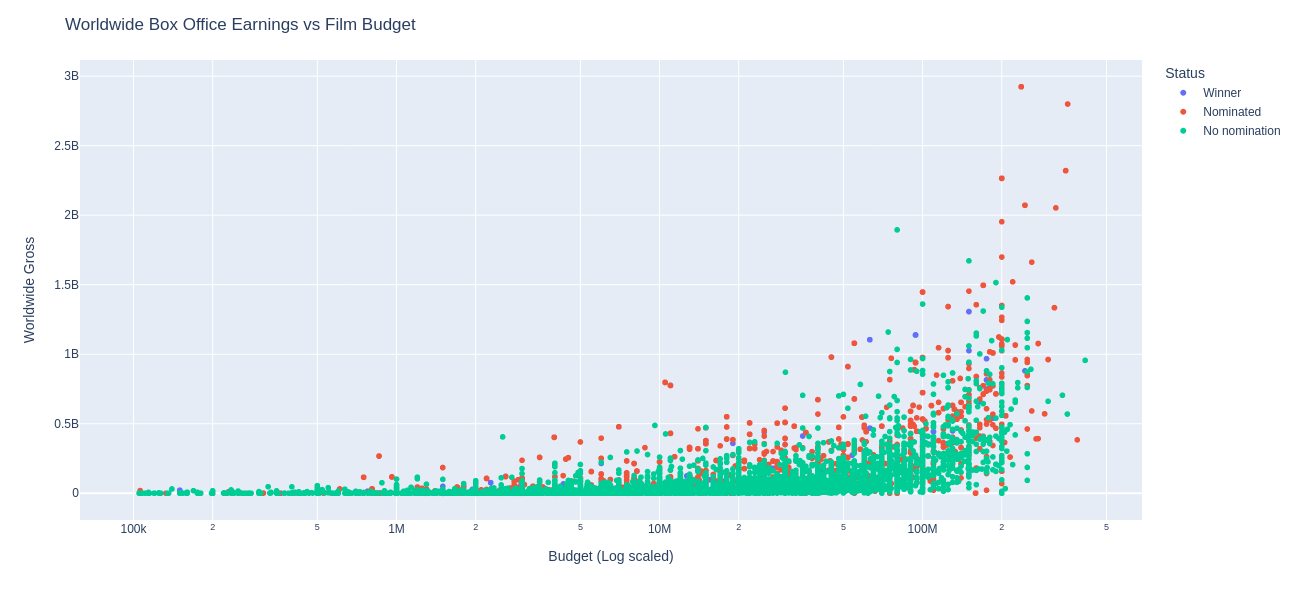

In [25]:
# x = combined_films['budget']
# y = combined_films['gross_worldwide']
df1 = to_graph[0]
df2 = to_graph[1]
df3 = to_graph[2]
df3 = df3.rename(columns={'title': 'Film'})

all_films_scatter = pd.concat([df1, df2, df3], ignore_index=True)
fig = px.scatter(all_films_scatter, x='rounded_budget', y='rounded_gross', color='Status',
                 labels={'rounded_budget': 'Budget', 'rounded_gross': 'Gross', 'rating': 'IMDb Rating'},
                 hover_data={
                     'rating': True,
                     'Film': True if 'Film' in all_films_scatter.columns else False
                }
        )
# fig = px.scatter(x, y, log_x=True, log_y=True)
fig.update_layout(xaxis=dict(type='log'), xaxis_title='Budget (Log scaled)', yaxis_title='Worldwide Gross', title='Worldwide Box Office Earnings vs Film Budget')
# fig.update_layout(yaxis=dict(type='log'))
# fig.update_layout(yaxis=dict(type='log'))
fig.update_layout(height=600)
fig.show(config={'displayModeBar': False})

In [26]:
# ToDo: Add scatter for revenue and color code profitability

### Create a profit column

In [ ]:
all_films_scatter['Profit'] = all_films_scatter['gross_worldwide'] - all_films_scatter['rounded_budget']

In [ ]:
# x = combined_films['budget']
# y = combined_films['gross_worldwide']
# df1 = to_graph[0]
# df2 = to_graph[1]
# df3 = to_graph[2]
# df3 = df3.rename(columns={'title': 'Film'})

# all_films_scatter = pd.concat([df1, df2, df3], ignore_index=True)
fig = px.scatter(all_films_scatter, x='rounded_budget', y='Profit', color='Status',
                hover_data={
                    'Film': True if 'Film' in all_films_scatter.columns else False
                }
        )
# fig = px.scatter(x, y, log_x=True, log_y=True)
# fig.update_layout(xaxis=dict(type='log'), xaxis_title='Budget (Log scaled)', yaxis_title='Worldwide Gross', title='Worldwide Box Office Earnings vs Film Budget')
# fig.update_layout(yaxis=dict(type='log'))
# fig.update_layout(yaxis=dict(type='log'))
fig.update_layout(height=600)
fig.show(config={'displayModeBar': False})

In [ ]:
profit_fig = px.scatter(
    all_films_scatter,
    x='budget',
    y='rounded_gross',
    size='votes',
    color='Status',
    hover_data=['Film'],
    labels={'rounded_budget': 'Budget', 'Profit': 'Profit', 'rounded_gross': 'Worldwide Gross'},
    title="Bubble Chart: Profit vs Budget vs Gross"
)
profit_fig.update_layout(height=700)
profit_fig.update_layout(xaxis=dict(type='log'), xaxis_title='Budget (Log scaled)', yaxis_title='Worldwide Gross', title='Worldwide Box Office Earnings vs Film Budget')
profit_fig.show()